# Predicting Heart Disease Using Machine Learning

This notebook looks into using various Python-based machine learning and data science libraries in an attempt to build a machine learning model capable of predicting whether or not someone has heart disease based on their medical attributes.

## Data Dictionary
- age: Displays the age of the individual.

- sex: Displays the gender of the individual using the following format : 1 = male 0 = female

- cp- Chest-pain type: displays the type of chest-pain experienced by the individual using the following format : 0 = typical angina 1 = atypical angina 2 = non — anginal pain 3 = asymptotic

- trestbps- Resting Blood Pressure: displays the resting blood pressure value of an individual in mmHg (unit). anything above 130-140 is typically cause for concern.

- chol- Serum Cholestrol: displays the serum cholesterol in mg/dl (unit)

- fbs- Fasting Blood Sugar: compares the fasting blood sugar value of an individual with 120mg/dl. If fasting blood sugar > 120mg/dl then : 1 (true) else : 0 (false) '>126' mg/dL signals diabetes

- restecg- Resting ECG : displays resting electrocardiographic results 0 = normal 1 = having ST-T wave abnormality 2 = left ventricular hyperthrophy

- thalach- Max heart rate achieved : displays the max heart rate achieved by an individual.

- exang- Exercise induced angina : 1 = yes 0 = no

- oldpeak- ST depression induced by exercise relative to rest: displays the value which is an integer or float.

- slope- Slope of the peak exercise ST segment : 0 = upsloping: better heart rate with excercise (uncommon) 1 = flat: minimal change (typical healthy heart) 2 = downsloping: signs of unhealthy heart

- ca- Number of major vessels (0–3) colored by flourosopy : displays the value as integer or float.

- thal : Displays the thalassemia : 1,3 = normal 6 = fixed defect 7 = reversible defect: no proper blood movement when excercising

- target : Displays whether the individual is suffering from heart disease or not : 1 = yes 0 = no



In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,RandomizedSearchCV,GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, RocCurveDisplay, precision_score, recall_score
from sklearn.preprocessing import StandardScaler


In [11]:
dataset = pd.read_csv("../data/heart-disease.csv")
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [18]:
dataset.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

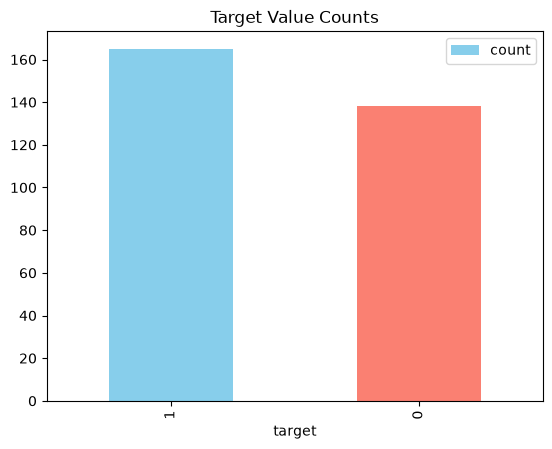

In [16]:
dataset["target"].value_counts().plot(kind="bar", color=["skyblue", "salmon"], title="Target Value Counts",legend=True)
plt.show()

In [17]:
dataset.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


# Heart Disease Frequency According To Sex

In [19]:
dataset['sex'].value_counts()

sex
1    207
0     96
Name: count, dtype: int64

In [23]:
# Compare target column with sex column
pd.crosstab(dataset['target'], dataset['sex'])


sex,0,1
target,,
0,24,114
1,72,93


<Figure size 1000x600 with 0 Axes>

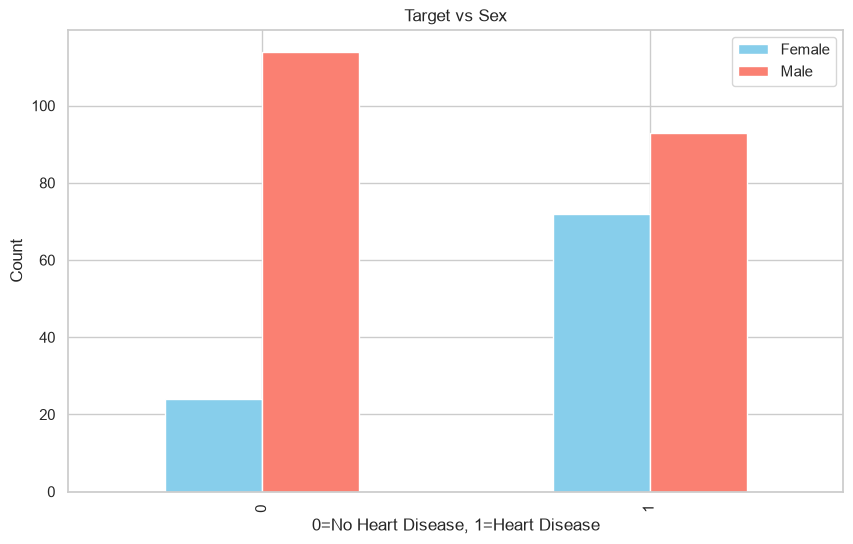

In [35]:
plt.figure(figsize=(10, 6))
pd.crosstab(dataset['target'], dataset['sex']).plot(kind="bar", color=["skyblue", "salmon"], title="Target vs Sex",legend=True)
plt.xlabel("0=No Heart Disease, 1=Heart Disease")
plt.ylabel("Count")
plt.legend(["Female", "Male"])
plt.show()

### Age vs. Max Heart Rate for Heart Disease

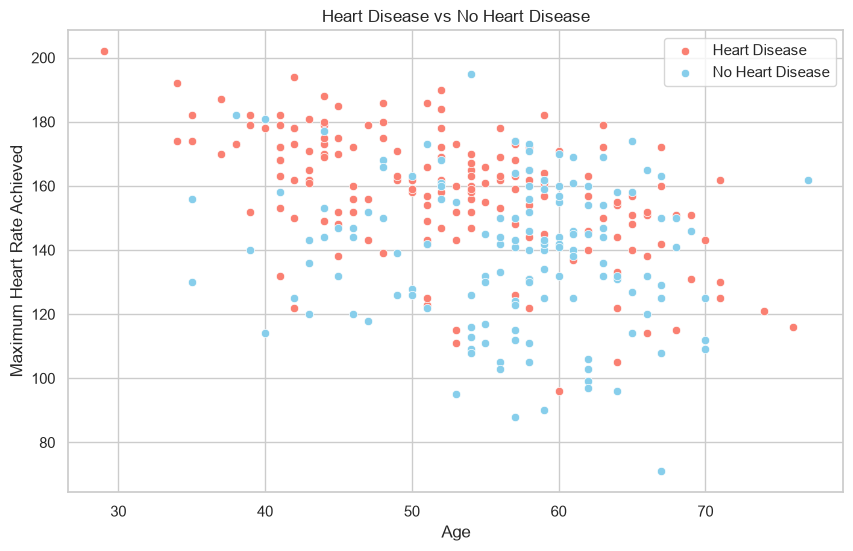

In [34]:
# create another figure
# plt.figure(figsize=(10, 6))
sns.set(rc={"figure.figsize":(10, 6)})
sns.set_style("whitegrid")
sns.scatterplot(
    data=dataset[dataset["target"] == 1],
    x="age",
    y="thalach",
    color="salmon",
    label="Heart Disease"
)
sns.scatterplot(
    data=dataset[dataset["target"] == 0],
    x="age",
    y="thalach",
    color="skyblue",
    label="No Heart Disease"
)
plt.xlabel("Age")
plt.ylabel("Maximum Heart Rate Achieved")
plt.title("Heart Disease vs No Heart Disease")
plt.legend()
plt.show()


# Check the distribution of the age with histogram

<Axes: ylabel='Frequency'>

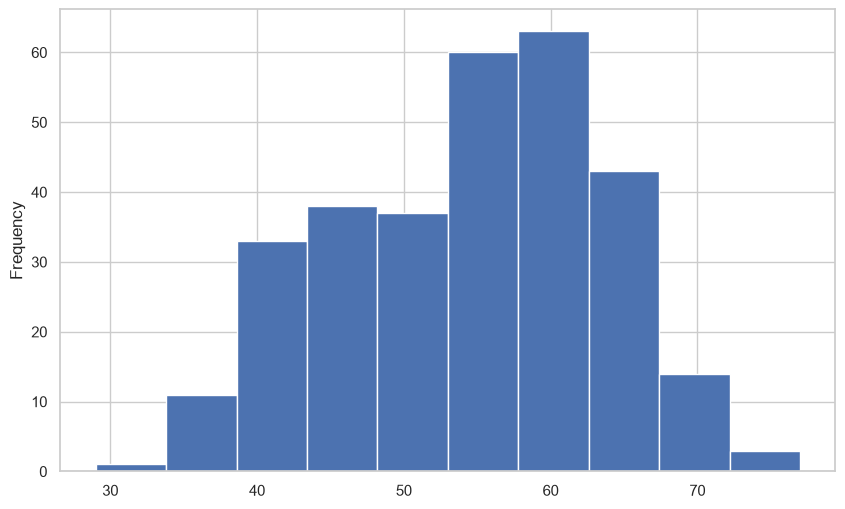

In [38]:
dataset.age.plot.hist()

# Heart Disease Frequency per Chest Pain Type

In [39]:
pd.crosstab(dataset['cp'], dataset['target'])

target,0,1
cp,,
0,104,39
1,9,41
2,18,69
3,7,16


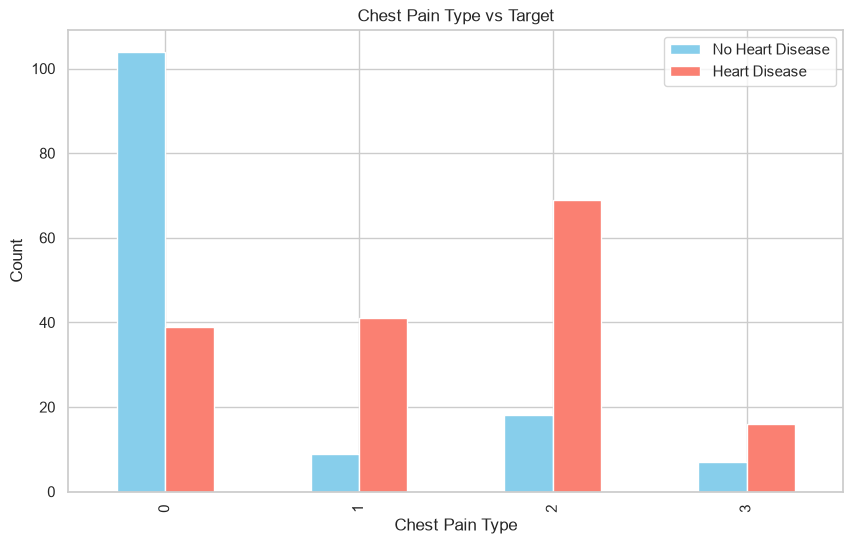

In [41]:
pd.crosstab(dataset['cp'], dataset['target']).plot(kind="bar", color=["skyblue", "salmon"], title="Chest Pain Type vs Target", legend=True)
plt.xlabel("Chest Pain Type")
plt.ylabel("Count")
plt.legend(["No Heart Disease", "Heart Disease"])
plt.show()